# Fase 3: Transfer Learning (Optimizado para GTX 1050 Ti)

En esta fase utilizamos un modelo preentrenado para resolver el problema de clasificación de *landmarks*, aplicando la técnica de Transfer Learning (congelando el extractor de características y entrenando un nuevo clasificador).

## 1. Justificación del Modelo Preentrenado

Se ha elegido la arquitectura **ResNet18**. 
* **Justificación técnica:** Las redes residuales (ResNet) solucionan el problema del desvanecimiento del gradiente en redes profundas mediante conexiones *skip*. ResNet18 ofrece un excelente equilibrio entre capacidad de representación (suficiente para extraer patrones complejos de arquitectura y paisajes) y eficiencia computacional.
* **Justificación de hardware:** Dado el límite de 4GB de VRAM en la GPU local (GTX 1050 Ti), ResNet18 permite utilizar un tamaño de lote (*batch size*) razonable sin provocar desbordamientos de memoria (OOM), garantizando un entrenamiento estable y rápido.

In [1]:
import os
import sys
from pathlib import Path

# Utilizamos exactamente las mismas rutas seguras de la Fase 2
PROJECT_DIR = Path(r"D:\DESCARGAS\PYPAUL\proyecto_1\landmark-classifier")
DATA_ROOT = Path(r"D:\DESCARGAS\PYPAUL\proyecto_1\Proyecto 1 Data set\landmark_images")

os.chdir(PROJECT_DIR)

print(f"Directorio del proyecto: {PROJECT_DIR}")
print(f"Ruta del dataset: {DATA_ROOT}")

assert DATA_ROOT.exists(), f"No se encontró el dataset en {DATA_ROOT}"

Directorio del proyecto: D:\DESCARGAS\PYPAUL\proyecto_1\landmark-classifier
Ruta del dataset: D:\DESCARGAS\PYPAUL\proyecto_1\Proyecto 1 Data set\landmark_images


## 2. Entrenamiento (Transfer Learning)
Procedemos a entrenar la nueva capa clasificadora final (`fc`). Como la red base ya sabe identificar bordes, texturas y formas, no necesitamos 35 épocas. Con **20 épocas** suele ser más que suficiente para que el modelo converja.

In [2]:
# Hiperparámetros adaptados a la gráfica y al Transfer Learning
BACKBONE = 'resnet18'
EPOCHS = 20  # Converge mucho más rápido que entrenar desde cero
BATCH_SIZE = 32 # Subimos a 32 porque ResNet18 es eficiente en memoria
LR = "1e-3" # Un learning rate un poco más alto funciona bien aquí
OUT_DIR = "outputs/transfer_run_gpu"
MODEL_PATH = "models/transfer_best_gpu.pt"

# Nota: Mantenemos --num-workers 2 y sin --amp para estabilidad
!{sys.executable} -u -m src.train \
    --data-root "{DATA_ROOT}" \
    --model-type transfer \
    --backbone {BACKBONE} \
    --epochs {EPOCHS} \
    --batch-size {BATCH_SIZE} \
    --lr {LR} \
    --weight-decay 1e-4 \
    --use-cosine-scheduler \
    --num-workers 2 \
    --checkpoint-every 5 \
    --output-dir "{OUT_DIR}" \
    --export-path "{MODEL_PATH}"

device=cuda
cudnn_benchmark=enabled
amp=True
classes=50, train_batches=125
epoch=001 train_loss=3.1985 train_acc=0.2409 val_loss=2.2363 val_acc=0.5095
epoch=002 train_loss=2.1243 train_acc=0.5181 val_loss=1.7779 val_acc=0.5836
epoch=003 train_loss=1.7319 train_acc=0.5974 val_loss=1.5123 val_acc=0.6486
epoch=004 train_loss=1.5079 train_acc=0.6405 val_loss=1.4007 val_acc=0.6697
epoch=005 train_loss=1.4047 train_acc=0.6565 val_loss=1.3388 val_acc=0.6877
checkpoint_epoch=outputs\transfer_run_gpu\checkpoints\epoch_005.pth
epoch=006 train_loss=1.2984 train_acc=0.6835 val_loss=1.3288 val_acc=0.6757
epoch=007 train_loss=1.2467 train_acc=0.6865 val_loss=1.2664 val_acc=0.6967
epoch=008 train_loss=1.2049 train_acc=0.6988 val_loss=1.2416 val_acc=0.6957
epoch=009 train_loss=1.1457 train_acc=0.7108 val_loss=1.2307 val_acc=0.6927
epoch=010 train_loss=1.1123 train_acc=0.7213 val_loss=1.2122 val_acc=0.6997
checkpoint_epoch=outputs\transfer_run_gpu\checkpoints\epoch_010.pth
epoch=011 train_loss=1.0993 t

d:\DESCARGAS\PYPAUL\proyecto_1\landmark-classifier\src\train.py:240: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=use_amp) if device.type == "cuda" else None


## 3. Evaluación Individual (Transfer Learning)
Verificamos que el modelo cumpla con el umbral de la rúbrica ($\ge 70\%$) y la bonificación ($\ge 75\%$).

--- RESUMEN TRANSFER LEARNING ---
Test Accuracy: 72.40%
Mejor Época: 20


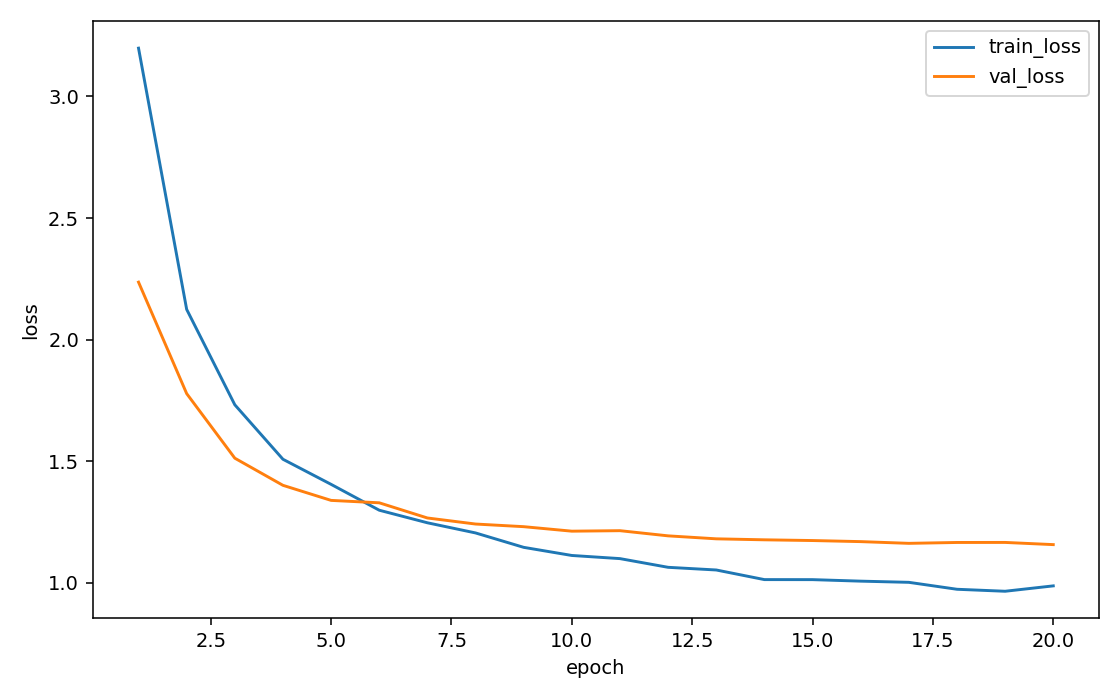

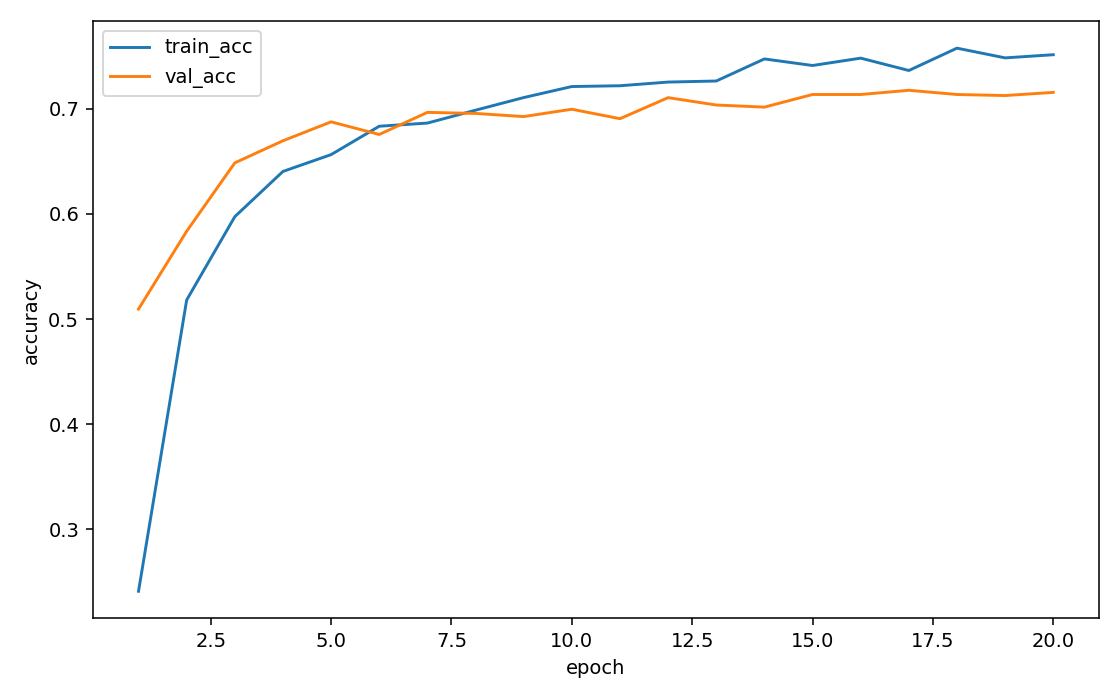

In [3]:
import json
import pandas as pd
from IPython.display import display, Image

# Cargar métricas
with open(f"{OUT_DIR}/summary.json", "r") as f:
    transfer_summary = json.load(f)

test_acc = transfer_summary['test_acc']
print("--- RESUMEN TRANSFER LEARNING ---")
print(f"Test Accuracy: {test_acc:.2%}")
print(f"Mejor Época: {transfer_summary.get('best_epoch', 'N/A')}")

# Verificación de rúbrica
assert test_acc >= 0.70, 'El modelo no alcanzó el 70% mínimo.'
if test_acc >= 0.75:
    print("🌟 ¡Excelente! Has conseguido el punto de bonificación (>= 75%).")

# Mostrar curvas
try:
    display(Image(filename=f'{OUT_DIR}/loss_curve.png', width=600))
    display(Image(filename=f'{OUT_DIR}/accuracy_curve.png', width=600))
except FileNotFoundError:
    print("Gráficos no encontrados.")

## 4. Comparación: Transfer Learning vs. Scratch
La rúbrica exige comparar los resultados de la Fase 3 con los obtenidos en la Fase 2. Usaremos el script de comparación apuntando a los resultados generados anteriormente.

             scratch | acc=49.92% | loss=2.3353 | backbone=None
            transfer | acc=72.40% | loss=1.0600 | backbone=resnet18

Comparación guardada en: outputs\comparison
# Comparación de Modelos

| Modelo | Tipo | Backbone | Epochs | Test Accuracy | Test Loss |
|---|---|---|---:|---:|---:|
| scratch | scratch | None | 35 | 49.92% | 2.3353 |
| transfer | transfer | resnet18 | 20 | 72.40% | 1.0600 |

- Scratch cumple umbral (40%): sí
- Transfer cumple umbral (70%): sí
- Transfer supera a scratch: sí


,model,model_type,backbone,epochs,test_acc,test_acc_pct,test_loss
0,scratch,scratch,NaN,35,0.4992,49.92,2.335260
1,transfer,transfer,resnet18,20,0.7240,72.40,1.060039


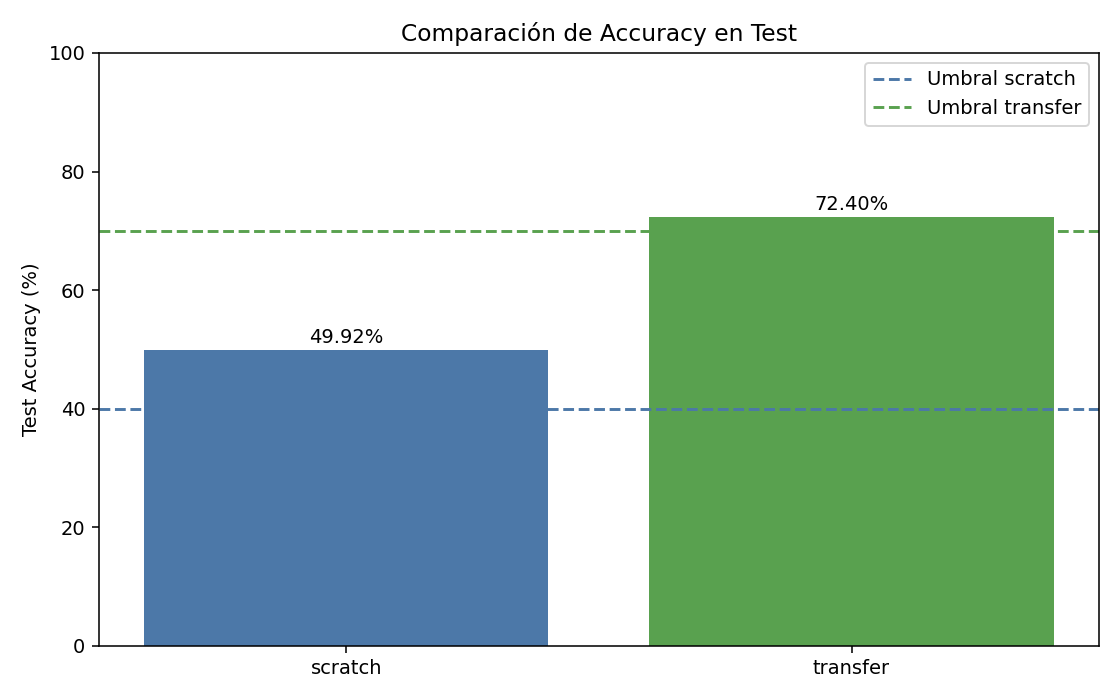

In [4]:
# Apuntamos el comparador al directorio donde guardaste los resultados de la Fase 2
SCRATCH_SUMMARY = "outputs/final_run_gpu/summary.json"
TRANSFER_SUMMARY = f"{OUT_DIR}/summary.json"
COMPARE_DIR = "outputs/comparison"

!{sys.executable} -m src.compare_models \
    --scratch-summary "{SCRATCH_SUMMARY}" \
    --transfer-summary "{TRANSFER_SUMMARY}" \
    --scratch-threshold 0.40 \
    --transfer-threshold 0.70 \
    --out-dir "{COMPARE_DIR}"

# Mostrar los resultados de la comparación
print(Path(f'{COMPARE_DIR}/model_comparison.md').read_text(encoding='utf-8'))
display(pd.read_csv(f'{COMPARE_DIR}/model_comparison.csv'))

try:
    display(Image(filename=f'{COMPARE_DIR}/test_accuracy_comparison.png', width=600))
except FileNotFoundError:
    print("Gráfico de comparación no generado.")